## Exploring HR with ML
In this notebook we work through a toy case

$\Delta \mu_{raw} = m_B(z) - M_{abs} - \mu_{\Lambda CDM}(z)\
= m_B(z) - M_{abs} + Normal(0, 0.1) - \mu_{\Lambda CDM}(z) $ \
$\Delta \mu_{corr} = m_B(z) + \alpha x_1 - \beta c - M_{abs}  - \mu_{\Lambda CDM}(z)$ 

Corectiong for x1 and c is what reduced the scatter on m_b.


$\Delta \mu_{raw} = F_1(x_1, c, hostmass, SFR, ...)\
=m_B(z, x_1, c, hostmass, SFR, ...) - M_{abs} + Normal(0, 0.1) - \mu_{\Lambda CDM}(z)$

Now let's assume 

$m_B(z, x_1, c, hostmass, SFR, ...) = m_B(z) - \alpha*x_1 + \beta*c - \gamma*hostmass + \alpha_2*x_1^2 + \beta_2*c^2 + \gamma_2*hostmass^2$

We want to use ML to predict $F_1$, then marginalize to recover the input non-linear relations.

Now that we have $F_1$, for a given set of ($x_1$, $c$, $hostmass$, ...), we can get an estimate of $\Delta \mu_{raw}$. We can then marginalize over all parameters to get $m_B(z)$ and fit for $M_{abs}$ and $\Lambda CDM$

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from astropy.cosmology import FlatLambdaCDM

### 1. We generate $\Delta \mu_{raw}$ as linear combinations of x1, c, hostmass plus a non-linear component.

In [2]:
N=10000
x1 = np.random.normal(loc=0, scale=1, size=N)
c = np.random.normal(loc=0, scale =0.1, size=N)
hostmass = np.random.uniform(7, 11, N)
alpha = 0.1
beta = 3.
gamma = 0.03
dm = np.random.normal(loc=0, scale=0.1, size=N)
alpha2 = -0.08
beta2 = 0.5
gamma2 = 0.002
dmu_raw = - alpha*x1 + beta*c - gamma*hostmass + dm + alpha2*x1**2 + beta2*c**2 + gamma2*hostmass**2
mean = np.mean(dmu_raw)
dmu_corr = dmu_raw + alpha*x1 - beta*c

Raw scatter: 0.34974943000037384
Scatter after linear x1 and c correction: 0.15378331612189525


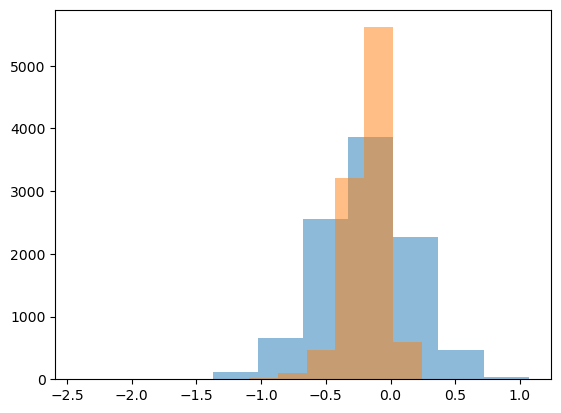

In [3]:
plt.hist(dmu_raw,alpha=0.5)
plt.hist(dmu_corr,alpha=0.5)
print("Raw scatter:",np.std(dmu_raw))
print("Scatter after linear x1 and c correction:",np.std(dmu_corr))

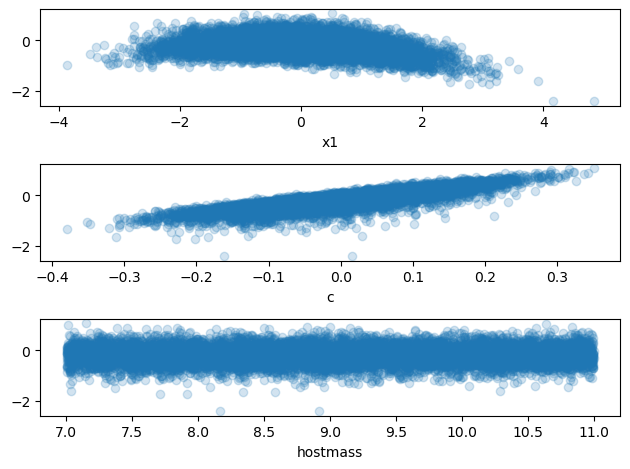

In [4]:
plt.subplot(3,1,1)
plt.scatter(x1, dmu_raw,alpha=0.2)
plt.xlabel('x1')
plt.subplot(3,1,2)
plt.scatter(c, dmu_raw,alpha=0.2)
plt.xlabel('c')
plt.subplot(3,1,3)
plt.scatter(hostmass, dmu_raw,alpha=0.2)
plt.xlabel('hostmass')
plt.tight_layout()
plt.show()

### 2. Now let's see what ML can help.

In [5]:
rf = RandomForestRegressor(
    n_estimators=1000,
    max_depth=None,
    min_samples_leaf=5,
    max_features="sqrt",
    bootstrap=True,
    n_jobs=-1,
    random_state=42,
)

In [6]:
features = {
    "x1": x1,
    "c": c,
    "hostmass": hostmass,
}

X = pd.DataFrame(features)
y = dmu_raw

Xtr, Xte, ytr, yte = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
yerr = 0.1
w = 1.0 / (yerr**2)
rf.fit(Xtr, ytr, sample_weight=w)
yhat = rf.predict(Xte)

In [8]:
rf.feature_importances_

array([0.21047733, 0.76266933, 0.02685335])

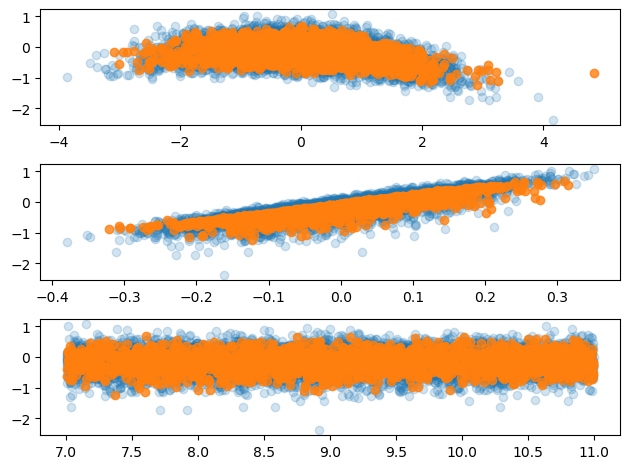

In [9]:
for i,p in enumerate(["x1","c","hostmass"]):
    plt.subplot(3,1,i+1)
    plt.scatter(Xtr[p], ytr,alpha=0.2)
    plt.scatter(Xte[p], yhat,alpha=0.8)
plt.tight_layout()

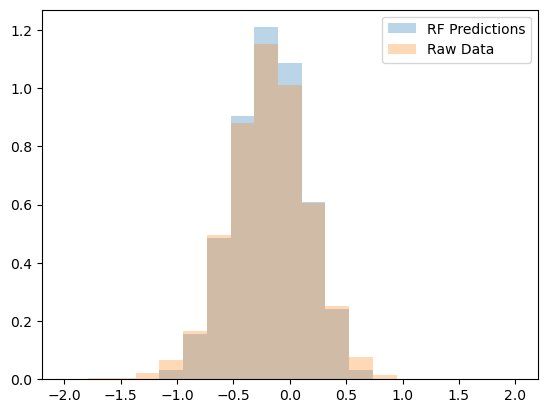

In [10]:
bins = np.linspace(-2,2,20)
plt.hist(yhat,alpha=0.3,density=True,bins=bins,label='RF Predictions')
plt.hist(y,alpha=0.3,density=True,bins=bins,label='Raw Data')
plt.legend()
plt.show()

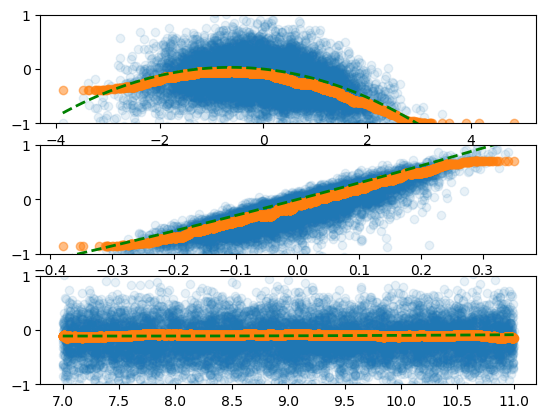

In [ ]:
# We have machine learning model where we can get x1 c and host mass and we get prediction of hubble residuals. Here there is no integration 
# being made but rather a mean value is taken. For Mykola: be sure to actually integrate as part of the marginalization process. 

for i,p in enumerate(["x1","c","hostmass"]):
    plt.subplot(3,1,i+1)
    Xtest = X.copy()
    for p2 in [pi for pi in ["x1","c","hostmass"] if pi != p]:
        Xtest[p2] = Xtest[p2].mean()
    ytest = rf.predict(Xtest)
    plt.scatter(Xtest[p],y,alpha=0.1,label="Raw data")
    plt.scatter(Xtest[p],ytest,alpha=0.5,label="predicted after marginalization")
    xplot = np.linspace(Xtest[p].min(),Xtest[p].max(),100)
    if p == "hostmass":
        yplot = -gamma*xplot + gamma2*xplot**2 
    elif p == "x1":
        yplot = -alpha*xplot + alpha2*xplot**2
    elif p == "c":
        yplot = beta*xplot + beta2*xplot**2
    plt.plot(xplot,yplot,c='g',lw=2,ls='--',label="input relation")
    plt.ylim((-1,1))
plt.show()

0.11625247580807212


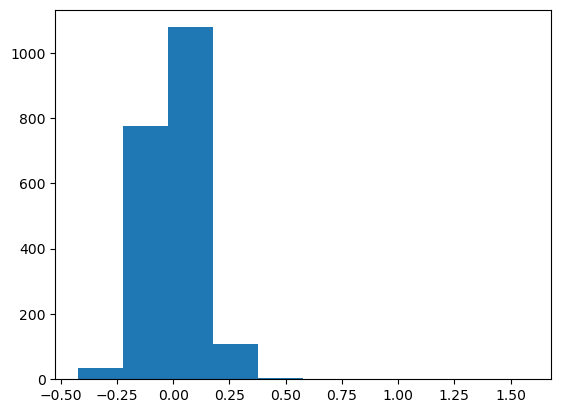

In [ ]:
# Make sure to do this as well. 

plt.hist(yhat-yte)
print(np.std(yhat-yte))

Text(0, 0.5, '$\\mu$')

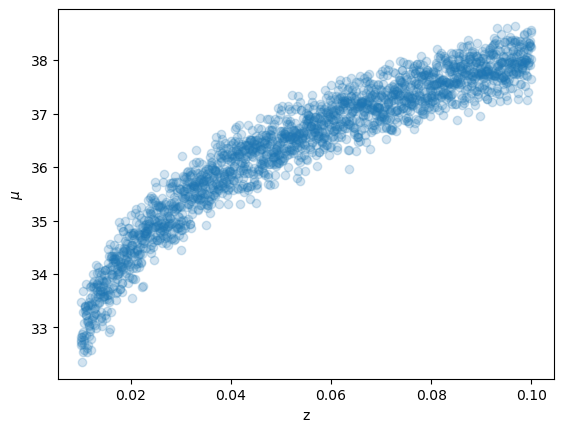

In [13]:
cosmo = FlatLambdaCDM(H0=73, Om0=0.3)
z = np.linspace(0.01,0.1,len(yhat))
mu = cosmo.distmod(z).value
mb = yhat + mu
plt.scatter(z,mb,alpha=0.2)
plt.xlabel('z')
plt.ylabel(r'$\mu$')